# RD first stage and reduced form
This notebook estimates the EFW first stage and reduced-form impacts of
close election outcomes on macro aggregates.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import ANALYSIS_DIR, PAPER_FIGURES_DIR, PAPER_TABLES_DIR
from src.rd import rd_binned_means, rd_estimate, select_bandwidth
from src.viz_style import savefig, set_style

In [2]:
set_style()

sample_path = ANALYSIS_DIR / "close_elections_sample.parquet"
if not sample_path.exists():
    raise FileNotFoundError("Missing close-election sample. Run 11_construct_close_elections_rd_sample first.")

sample = pd.read_parquet(sample_path)

RUNNING = "running_var"
bandwidth = select_bandwidth(sample[RUNNING], quantile=0.3, max_bw=0.2)
if pd.isna(bandwidth):
    raise ValueError("Unable to select RD bandwidth.")

In [3]:
first_stage = rd_estimate(
    sample.dropna(subset=["efw_post_1_3"]),
    "efw_post_1_3",
    RUNNING,
    bandwidth=bandwidth,
    cluster="iso3c",
)

first_stage_df = pd.DataFrame(
    [
        {
            "outcome": "efw_post_1_3",
            "coef": first_stage.coef,
            "se": first_stage.se,
            "pvalue": first_stage.pvalue,
            "n_obs": first_stage.n_obs,
            "bandwidth": first_stage.bandwidth,
        }
    ]
)
PAPER_TABLES_DIR.mkdir(parents=True, exist_ok=True)
first_stage_path = PAPER_TABLES_DIR / "rd_first_stage.csv"
first_stage_df.to_csv(first_stage_path, index=False)
display(first_stage_df.style.set_caption("RD first stage: Z -> EFW"))

,outcome,coef,se,pvalue,n_obs,bandwidth
0,efw_post_1_3,-0.295707,0.160265,0.065021,84,0.045455


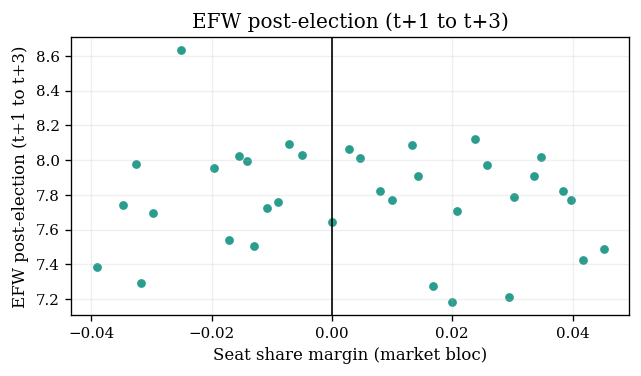

In [4]:
def plot_rd(outcome: str, label: str) -> None:
    subset = sample.dropna(subset=[outcome])
    bins = rd_binned_means(subset, outcome, RUNNING, bandwidth=bandwidth)
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(bins["bin_center"], bins["mean_outcome"], s=18, color="#2A9D8F")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Seat share margin (market bloc)")
    ax.set_ylabel(label)
    display(fig)
    savefig(fig, PAPER_FIGURES_DIR / "first_stage" / f"rd_{outcome}")
    plt.close(fig)


plot_rd("efw_post_1_3", "EFW post-election (t+1 to t+3)")

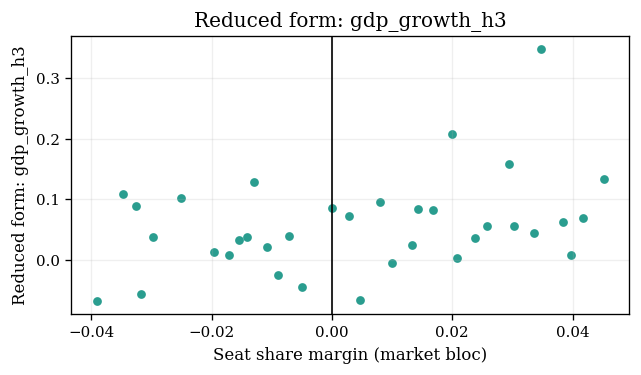

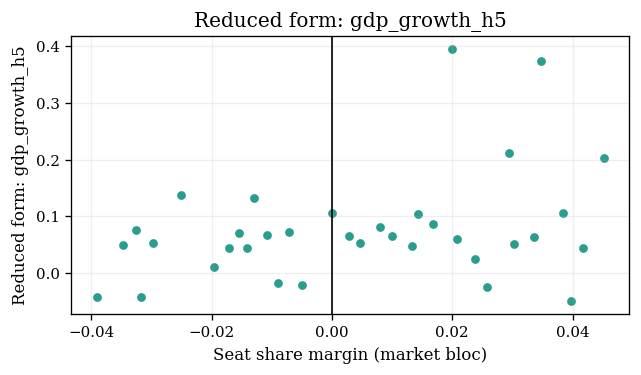

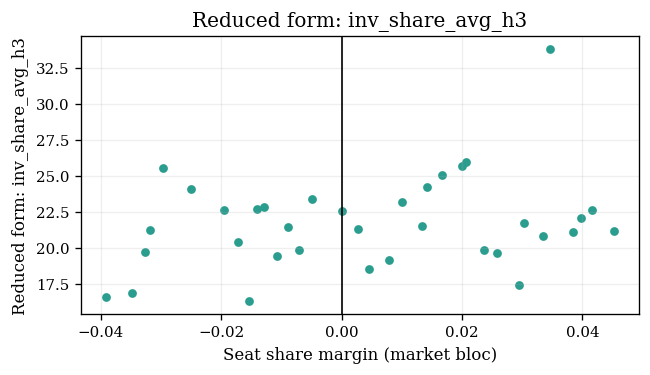

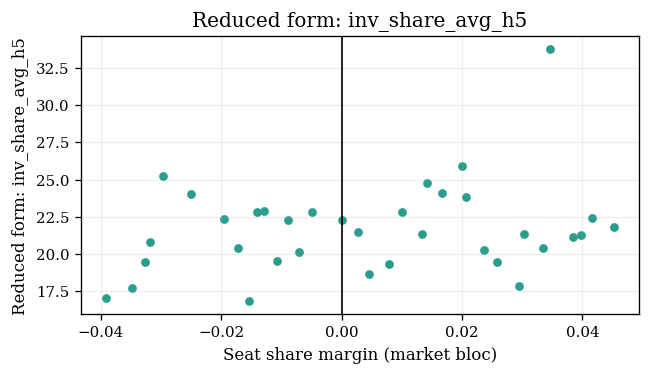

,outcome,coef,se,pvalue,n_obs,bandwidth
0,gdp_growth_h3,0.076106,0.036316,0.036111,84,0.045455
1,gdp_growth_h5,0.068817,0.037125,0.063786,84,0.045455
2,inv_share_avg_h3,0.264701,1.372457,0.847063,84,0.045455
3,inv_share_avg_h5,0.117885,1.339827,0.929888,84,0.045455


In [5]:
reduced_form_outcomes = [
    "gdp_growth_h3",
    "gdp_growth_h5",
    "inv_share_avg_h3",
    "inv_share_avg_h5",
]

rf_rows = []
for outcome in reduced_form_outcomes:
    if outcome not in sample.columns:
        continue
    estimate = rd_estimate(
        sample.dropna(subset=[outcome]),
        outcome,
        RUNNING,
        bandwidth=bandwidth,
        cluster="iso3c",
    )
    rf_rows.append(
        {
            "outcome": outcome,
            "coef": estimate.coef,
            "se": estimate.se,
            "pvalue": estimate.pvalue,
            "n_obs": estimate.n_obs,
            "bandwidth": estimate.bandwidth,
        }
    )
    plot_rd(outcome, f"Reduced form: {outcome}")

rf_df = pd.DataFrame(rf_rows)
rf_path = PAPER_TABLES_DIR / "rd_reduced_form.csv"
rf_df.to_csv(rf_path, index=False)
display(rf_df.style.set_caption("RD reduced form: Z -> outcomes"))

## Interpretation
The first-stage and reduced-form estimates establish whether close market
victories shift EFW and whether outcomes respond at the cutoff. These
results inform whether an RD-IV interpretation is warranted.